# K Nearest Neighbors Project 

Welcome to the KNN Project! This will be a simple project very similar to the lecture, except you'll be given another data set. Go ahead and just follow the directions below.
## Import Libraries
**Import pandas,seaborn, and the usual libraries.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

%matplotlib inline

## Get the Data
** Read the 'KNN_Project_Data csv file into a dataframe **

In [2]:
df = pd.read_csv('KNN_Project_Data.csv')

**Check the head of the dataframe.**

In [3]:
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


# EDA

Since this data is artificial, we'll just do a large pairplot with seaborn.

**Use seaborn on the dataframe to create a pairplot with the hue indicated by the TARGET CLASS column.**

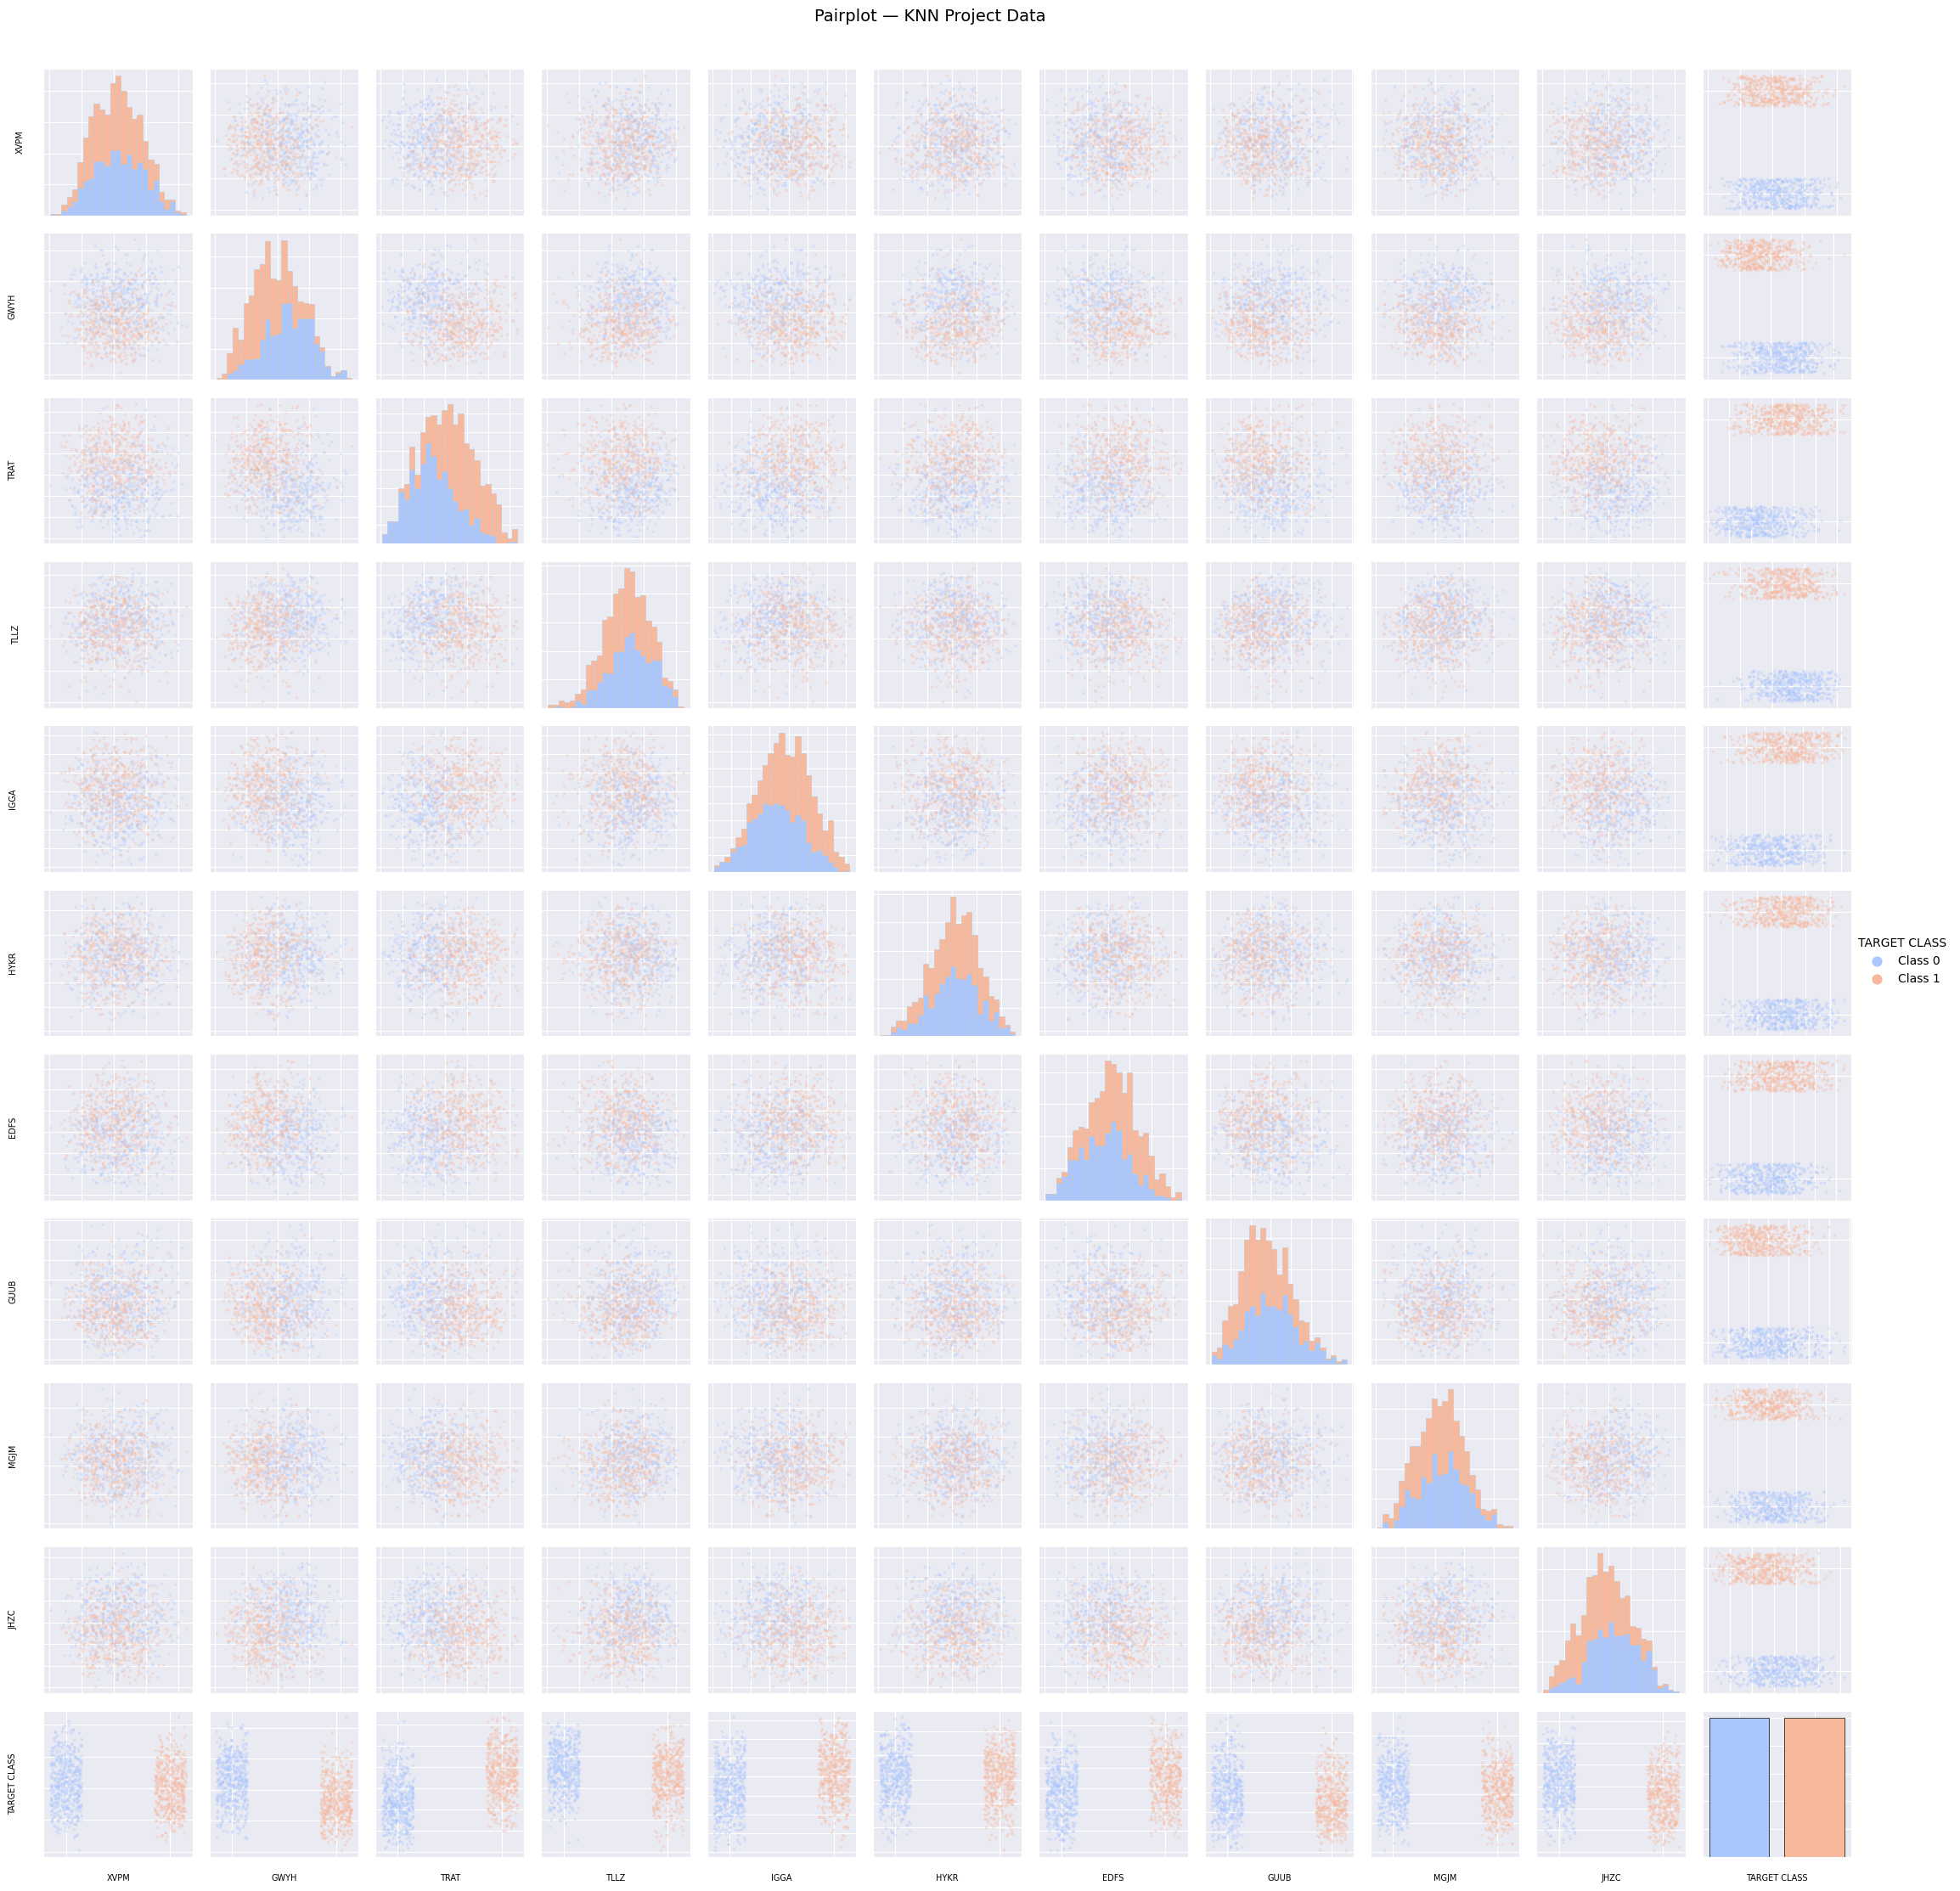

In [4]:
palette = {0: '#AAC7FD', 1: '#F7B89C'}
plot_cols = [c for c in df.columns if c != 'TARGET CLASS'] + ['TARGET CLASS']
n, hue_vals = len(plot_cols), sorted(df['TARGET CLASS'].unique())
rng = np.random.RandomState(42)

fig, axes = plt.subplots(n, n, figsize=(22, 22))
fig.subplots_adjust(hspace=0.3, wspace=0.3, right=0.88)

for i, rv in enumerate(plot_cols):
    for j, cv in enumerate(plot_cols):
        ax = axes[i, j]
        ax.set_facecolor('#EAEAF2')
        ax.grid(True, color='white', linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors='white', labelsize=5)
        for sp in ax.spines.values(): sp.set_edgecolor('white')

        if i == j:
            if rv == 'TARGET CLASS':
                counts = df['TARGET CLASS'].value_counts().sort_index()
                ax.bar(counts.index, counts.values, color=[palette[k] for k in counts.index],
                       edgecolor='black', linewidth=0.5)
                ax.set_xticks([0, 1])
            else:
                bins = np.histogram_bin_edges(df[rv], bins=25)
                w, l = np.diff(bins), bins[:-1]
                c0, c1 = [np.histogram(df.loc[df['TARGET CLASS'] == cls, rv], bins)[0] for cls in hue_vals]
                for bottom, counts, cls in [(None, c0, 0), (c0, c1, 1)]:
                    ax.bar(l, counts, width=w, align='edge', bottom=bottom,
                           color=palette[cls], edgecolor='#C9C1C2', linewidth=0.4)

        elif rv == 'TARGET CLASS' or cv == 'TARGET CLASS':
            for cls in hue_vals:
                mask = df['TARGET CLASS'] == cls
                feat, is_x = (rv, False) if cv == 'TARGET CLASS' else (cv, True)
                jit = rng.uniform(-0.15, 0.15, mask.sum())
                base = np.full(mask.sum(), cls) + jit
                xy = (base, df.loc[mask, feat]) if is_x else (df.loc[mask, feat], base)
                ax.scatter(*xy, color=palette[cls], alpha=0.35, s=6, linewidths=0)
                (ax.set_xticks if is_x else ax.set_yticks)([0, 1])
        else:
            for cls in hue_vals:
                mask = df['TARGET CLASS'] == cls
                ax.scatter(df.loc[mask, cv], df.loc[mask, rv],
                           color=palette[cls], alpha=0.3, s=6, linewidths=0)

        if i == n - 1: ax.set_xlabel(cv, fontsize=7, labelpad=3, color='black')
        else: ax.set_xticklabels([])
        if j == 0: ax.set_ylabel(rv, fontsize=7, labelpad=3, color='black')
        else: ax.set_yticklabels([])

fig.legend(handles=[plt.scatter([], [], color=palette[k], label=f'Class {k}', s=60) for k in hue_vals],
           loc='center right', fontsize=10, frameon=False, title='TARGET CLASS',
           bbox_to_anchor=(1.05, 0.5))
fig.suptitle('Pairplot — KNN Project Data', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Standardize the Variables

Time to standardize the variables.

** Import StandardScaler from Scikit learn.**

In [5]:
from sklearn.preprocessing import StandardScaler

** Create a StandardScaler() object called scaler.**

In [6]:
scaler = StandardScaler()

** Fit scaler to the features.**

In [7]:
scaler.fit(df.drop('TARGET CLASS', axis=1))

StandardScaler()

**Use the .transform() method to transform the features to a scaled version.**

In [8]:
scaled_features = scaler.transform(df.drop('TARGET CLASS', axis=1))

**Convert the scaled features to a dataframe and check the head of this dataframe to make sure the scaling worked.**

In [9]:
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df_feat.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC
0,1.568522,-0.443435,1.619808,-0.958255,-1.128481,0.138336,0.980493,-0.932794,1.008313,-1.069627
1,-0.112376,-1.056574,1.741918,-1.504220,0.640009,1.081552,-1.182663,-0.461864,0.258321,-1.041546
2,0.660647,-0.436981,0.775793,0.213394,-0.053171,2.030872,-1.240707,1.149298,2.184784,0.342811
3,0.011533,0.191324,-1.433473,-0.100053,-1.507223,-1.753632,-1.183561,-0.888557,0.162310,-0.002793
4,-0.099059,0.820815,-0.904346,1.609015,-0.282065,-0.365099,-1.095644,0.391419,-1.365603,0.787762


# Train Test Split

**Use train_test_split to split your data into a training set and a testing set.**

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_features, df['TARGET CLASS'], test_size=0.30, random_state=1071
)

# Using KNN

**Import KNeighborsClassifier from scikit learn.**

In [12]:
from sklearn.neighbors import KNeighborsClassifier

**Create a KNN model instance with n_neighbors=1**

In [13]:
knn = KNeighborsClassifier(n_neighbors=1)

**Fit this KNN model to the training data.**

In [14]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

# Predictions and Evaluations
Let's evaluate our KNN model!

**Use the predict method to predict values using your KNN model and X_test.**

In [15]:
pred = knn.predict(X_test)

** Create a confusion matrix and classification report.**

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
print(confusion_matrix(y_test, pred))

[[115  37]
 [ 31 117]]


In [18]:
r = classification_report(y_test, pred, output_dict=True)

fmt = '{:>15} {:>10} {:>10} {:>10} {:>10}'.format
print(fmt('', 'precision', 'recall', 'f1-score', 'support'))
for cls in ['0', '1']:
    print(fmt(cls, *[f'{r[cls][m]:.2f}' for m in ['precision','recall','f1-score']], int(r[cls]['support'])))
wa = r['weighted avg']
print(fmt('avg / total', *[f'{wa[m]:.2f}' for m in ['precision','recall','f1-score']], int(r['0']['support']+r['1']['support'])))

                 precision     recall   f1-score    support
              0       0.79       0.76       0.77        152
              1       0.76       0.79       0.77        148
    avg / total       0.77       0.77       0.77        300


# Choosing a K Value
Let's go ahead and use the elbow method to pick a good K Value!

** Create a for loop that trains various KNN models with different k values, then keep track of the error_rate for each of these models with a list. Refer to the lecture if you are confused on this step.**

In [19]:
error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

**Now create the following plot using the information from your for loop.**

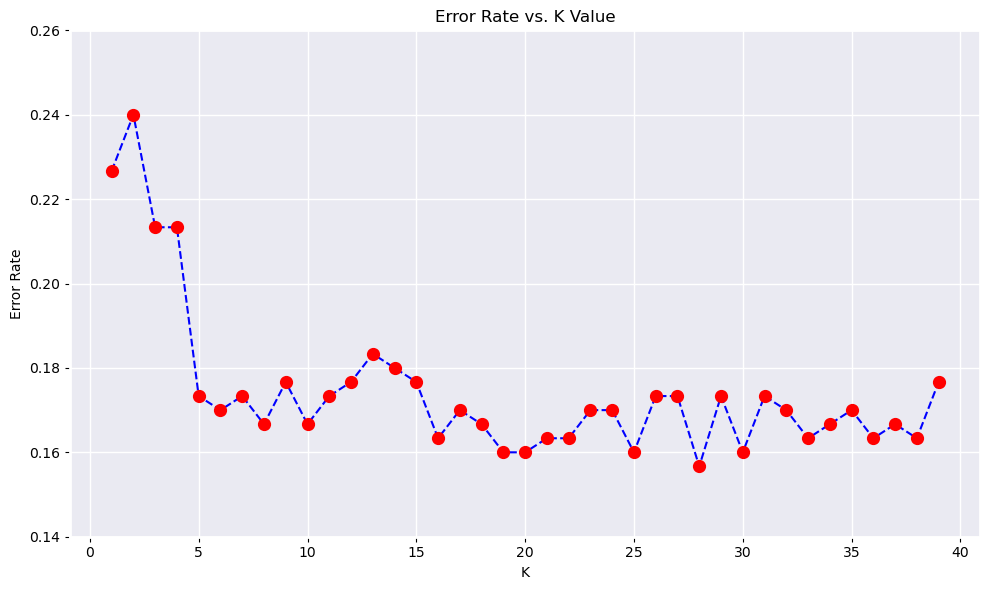

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_facecolor('#EAEAF2')
fig.patch.set_facecolor('white')

ax.grid(True, color='white', linewidth=1)
ax.plot(range(1, 40), error_rate, color='blue', linestyle='dashed',
        marker='o', markerfacecolor='red', markeredgecolor='red',
        markeredgewidth=1.5, markersize=8)

ax.set_title('Error Rate vs. K Value')
ax.set_xlabel('K')
ax.set_ylabel('Error Rate')
ax.set_ylim(0.14, 0.26)

for spine in ax.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()

## Retrain with new K Value

**Retrain your model with the best K value (up to you to decide what you want) and re-do the classification report and the confusion matrix.**

In [21]:
knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
r = classification_report(y_test, pred, output_dict=True)

print('WITH K=30\n')
print(confusion_matrix(y_test, pred), '\n')

fmt = '{:>10} {:>10} {:>10} {:>10} {:>10}'.format
print(fmt('', 'precision', 'recall', 'f1-score', 'support'))
for cls in ['0', '1']:
    print(fmt(cls, *[f'{r[cls][m]:.2f}' for m in ['precision','recall','f1-score']], int(r[cls]['support'])))
wa = r['weighted avg']
print(fmt('\navg/total', *[f'{wa[m]:.2f}' for m in ['precision','recall','f1-score']], int(r['0']['support']+r['1']['support'])))

WITH K=30

[[127  25]
 [ 23 125]] 

            precision     recall   f1-score    support
         0       0.85       0.84       0.84        152
         1       0.83       0.84       0.84        148

avg/total       0.84       0.84       0.84        300


## End of notebook